# Bachelor thesis modelling template

This Notebook presents a system including agricultural wheat production, subsequent treatment of residues (wheat straw) and the effect on atmosphere, surface water and aquifer and soil (see Figure 1). 

The aim was obtaining information on the impact of the application of agricultural residue treatment products as soil conditioner on the carbon stock of the soil. For the analysis, the system is investigated on good (Biomass from agricultural production) and substance level (Carbon) and is dynamically modeled for the years 2020 until 2040. 
Known input data are good and carbon imports from the cultivation, transfer coefficients for all processes (except soil carbon mineralization processes, which are calculated as first order model process (FOMP)) and standard deviation of all given values. Analysis results are displayed as Sankey diagram and uncertainty evaluation is performed via Monte Carlo Simulation  with log-normal distribution of transfer coefficients as approximation standard. The case study input data are arbitrarily chosen and only meant to demonstrate the templates methodology. 

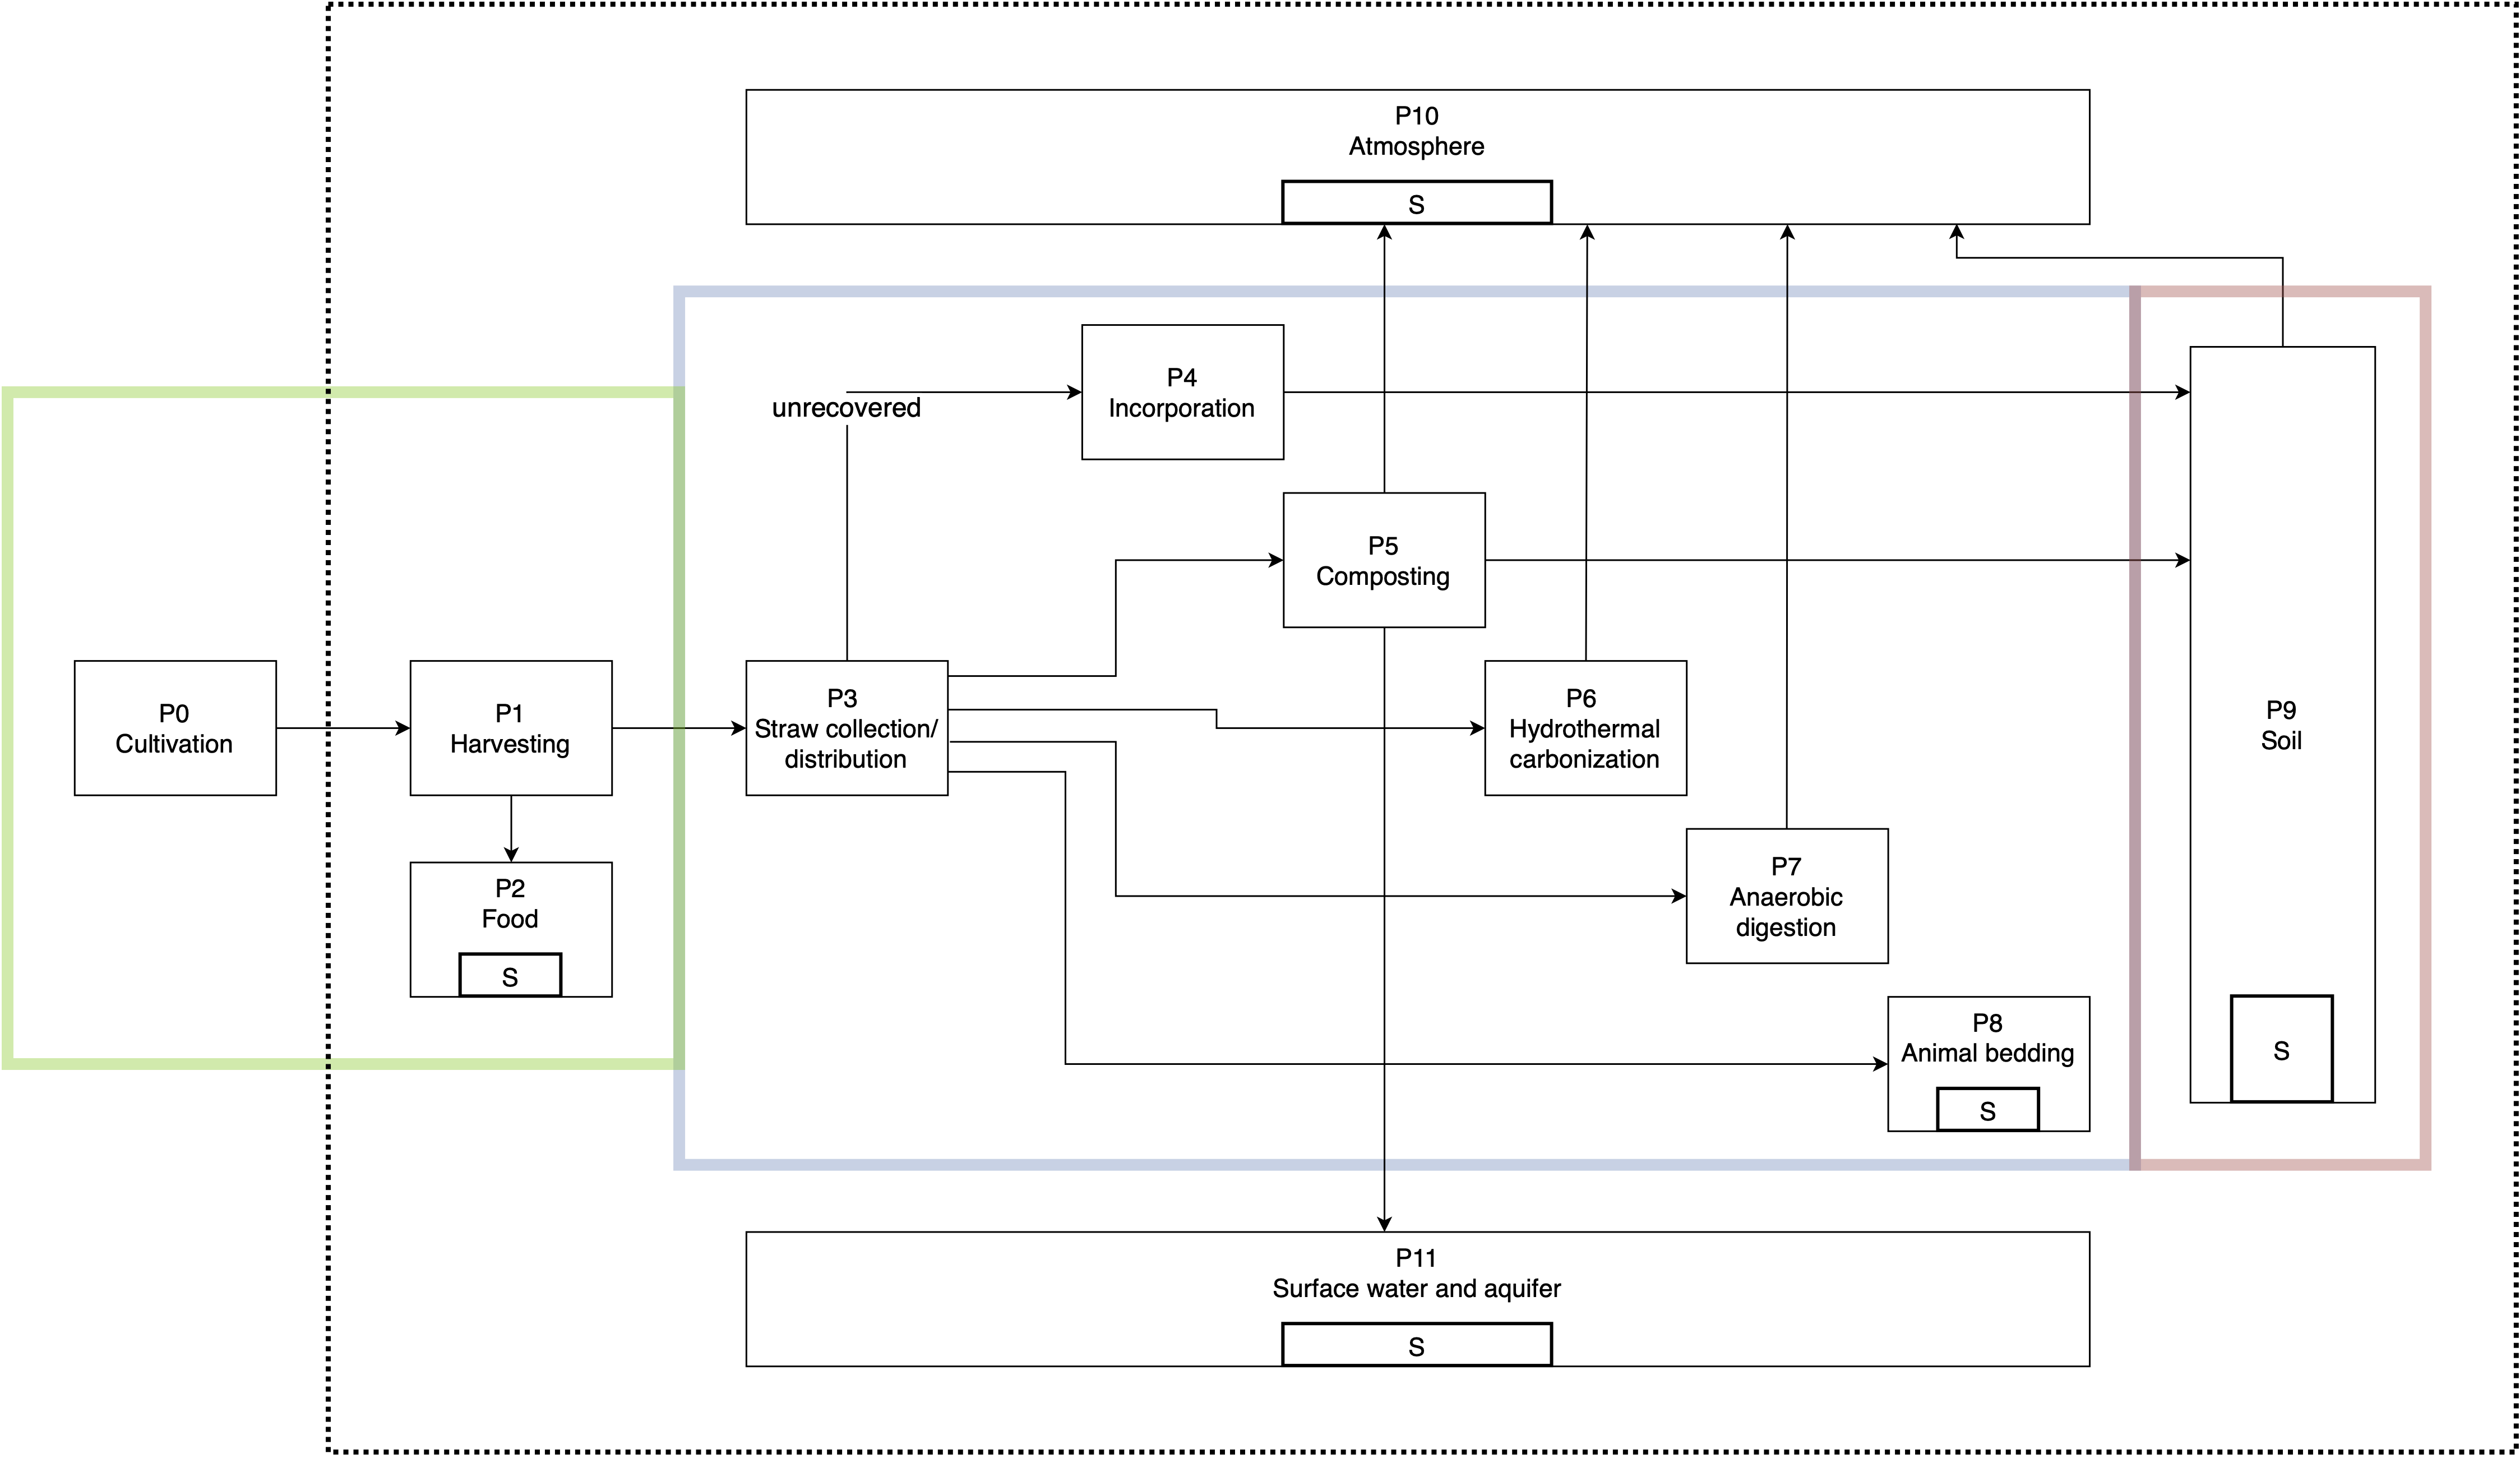
Figure 1: Case study MFA system including agricultural production (green), waste treatment (blue) and mineralization processes of soil conditioner products (red)


## 0 Load packages

In [1]:
### Load packages ###

# Load general libraries
import sys, os
import numpy as np
import pandas as pd
from scipy.stats import lognorm
import xlsxwriter
import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator,
                               FormatStrFormatter,
                               AutoMinorLocator)
import warnings
import re
from collections import defaultdict
from scipy.optimize import minimize
import copy

# Load ODYM package
# Add ODYM module directory to system path, absolute
sys.path.insert(0, os.path.join(os.path.dirname(os.path.dirname(os.getcwd())),'framework', 'ODYM-master_20241127', 'odym', 'modules')) 

# Import the ODYM class file
import ODYM_Classes as msc 
# Import the ODYM function file
import ODYM_Functions as msf
# Import the dynamic stock model library
import dynamic_stock_model as dsm 


# Load bioDYM_addon
# Add ODYM module directory to system path, absolute
sys.path.insert(0, os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), 'framework', 'bioDYM_add-on', 'modules')) 

# Import classes for first order model process
import bioDYM_classes as bicl
# Import plotting functions
import bioDYM_plotting as bipl
# Import export functions
import bioDYM_export as bix




# Enables plotting directly in the notebook (in most cases this is already enabled)
%matplotlib inline

## 1 Definition of system and relevant aspects

In [2]:
ModelClassification  = {} # Create empty dictionary of model classifications

MyYears = list(np.arange(2020,2041)) # Define period of analysis and create list of years
ModelClassification['Time'] = msc.Classification(Name = 'Time', Dimension = 'Time', ID = 1,
                                                 Items = MyYears)
# Classification for time labelled 'Time' must always be present, with Items containing a list of ordered integers representing years, months, or other discrete time intervals


ModelClassification['Element'] = msc.Classification(Name = 'Elements', Dimension = 'Element', 
                                                    ID = 2, Items = ['Biomass', 'C'])
# Classification for elements labelled 'Element' must always be present, with Items containing a list of the symbols of the elements covered.
# Here, other elements (like N or P) could be added to the ODYM MFA system

# Get model time start, end, and duration:
Model_Time_Start = int(min(ModelClassification['Time'].Items))
Model_Time_End   = int(max(ModelClassification['Time'].Items))
Model_Duration   = Model_Time_End - Model_Time_Start


In [3]:
IndexTable = pd.DataFrame({'Aspect'        : ['Time','Element'], # 'Time' and 'Element' must be present!
                           'Description'   : ['Model aspect "time"', 'Model aspect "Element"'],
                           'Dimension'     : ['Time','Element'], # 'Time' and 'Element' are also dimensions
                           'Classification': [ModelClassification[Aspect] for Aspect in ['Time','Element']],
                           'IndexLetter'   : ['t','e']}) # Unique one letter (upper or lower case) indices to be used later for calculations.

IndexTable.set_index('Aspect', inplace = True) # Default indexing of IndexTable, other indices are produced on the fly

IndexTable #Classification refers to ODYM structure, is not relevant for using the template 

,Description,Dimension,Classification,IndexLetter
Aspect,,,,
Time,"Model aspect ""time""",Time,<ODYM_Classes.Classification object at 0x00000...,t
Element,"Model aspect ""Element""",Element,<ODYM_Classes.Classification object at 0x00000...,e


In [4]:
# Initialize MFA system
Dyn_MFA_System = msc.MFAsystem(Name = 'TestSystem', 
                      Geogr_Scope = 'TestRegion', 
                      Unit = 't', 
                      ProcessList = [], 
                      FlowDict = {}, 
                      StockDict = {},
                      ParameterDict = {}, 
                      Time_Start = Model_Time_Start, 
                      Time_End = Model_Time_End, 
                      IndexTable = IndexTable, 
                      Elements = IndexTable.loc['Element'].Classification.Items) 

In [5]:
# Define all processes and specify an ID (ID is used to assign flows and stocks to processes)
Dyn_MFA_System.ProcessList = [] 
Dyn_MFA_System.ProcessList.append(msc.Process(Name = 'Cultivation' , ID   = 0))
Dyn_MFA_System.ProcessList.append(msc.Process(Name = 'Harvesting'    , ID   = 1))
Dyn_MFA_System.ProcessList.append(msc.Process(Name = 'Food'    , ID   = 2))
Dyn_MFA_System.ProcessList.append(msc.Process(Name = 'Straw c&d'  , ID   = 3))
Dyn_MFA_System.ProcessList.append(msc.Process(Name = 'Incorporation'   , ID   = 4))
Dyn_MFA_System.ProcessList.append(msc.Process(Name = 'Composting'   , ID   = 5))
Dyn_MFA_System.ProcessList.append(msc.Process(Name = 'HTC'  , ID   = 6))
Dyn_MFA_System.ProcessList.append(msc.Process(Name = 'AD'  , ID   = 7))
Dyn_MFA_System.ProcessList.append(msc.Process(Name = 'Animal bedding'  , ID   = 8))
Dyn_MFA_System.ProcessList.append(msc.Process(Name = 'Soil'  , ID   = 9))
Dyn_MFA_System.ProcessList.append(msc.Process(Name = 'Atmosphere'  , ID   = 10))
Dyn_MFA_System.ProcessList.append(msc.Process(Name = 'Surface water and aquifer'  , ID   = 11))


In [6]:
# FlowDict is part of the ODYM data base 
# Define the flows of the system
# Parameters have the following attributes:
    # Name: Choose name
    # P_Start: Which process initiates the flow
    # P_End: Target process
    # Indices: The flows in this case depend on time and the element investigated
    # Values: Values get assigned later, that is why in the cell the are specified as "None"

Dyn_MFA_System.FlowDict['F_0_1'] = msc.Flow(Name = 'F_0_1', P_Start = 0, P_End = 1,
                                            Indices = 't,e', Values=None)
Dyn_MFA_System.FlowDict['F_1_2'] = msc.Flow(Name = 'F_1_2', P_Start = 1, P_End = 2,
                                            Indices = 't,e', Values=None)
Dyn_MFA_System.FlowDict['F_1_3'] = msc.Flow(Name = 'F_1_3', P_Start = 1, P_End = 3,
                                            Indices = 't,e', Values=None)
Dyn_MFA_System.FlowDict['F_3_4'] = msc.Flow(Name = 'F_3_4', P_Start = 3, P_End = 4,
                                            Indices = 't,e', Values=None)
Dyn_MFA_System.FlowDict['F_3_5'] = msc.Flow(Name = 'F_3_5', P_Start = 3, P_End = 5,
                                            Indices = 't,e', Values=None)
Dyn_MFA_System.FlowDict['F_3_6'] = msc.Flow(Name = 'F_3_6', P_Start = 3, P_End = 6,
                                            Indices = 't,e', Values=None)
Dyn_MFA_System.FlowDict['F_3_7'] = msc.Flow(Name = 'F_3_7', P_Start = 3, P_End = 7,
                                            Indices = 't,e', Values=None)
Dyn_MFA_System.FlowDict['F_3_8'] = msc.Flow(Name = 'F_3_8', P_Start = 3, P_End = 8,
                                            Indices = 't,e', Values=None)
Dyn_MFA_System.FlowDict['F_4_9'] = msc.Flow(Name = 'F_4_9', P_Start = 4, P_End = 9,
                                            Indices = 't,e', Values=None)
Dyn_MFA_System.FlowDict['F_5_9'] = msc.Flow(Name = 'F_5_9', P_Start = 5, P_End = 9,
                                            Indices = 't,e', Values=None)
Dyn_MFA_System.FlowDict['F_5_10'] = msc.Flow(Name = 'F_5_10', P_Start = 5, P_End = 10,
                                            Indices = 't,e', Values=None)
Dyn_MFA_System.FlowDict['F_5_11'] = msc.Flow(Name = 'F_5_11', P_Start = 5, P_End = 11,
                                            Indices = 't,e', Values=None)
Dyn_MFA_System.FlowDict['F_6_10'] = msc.Flow(Name = 'F_6_10', P_Start = 6, P_End = 10,
                                            Indices = 't,e', Values=None)
Dyn_MFA_System.FlowDict['F_7_10'] = msc.Flow(Name = 'F_7_10', P_Start = 7, P_End = 10,
                                            Indices = 't,e', Values=None)
Dyn_MFA_System.FlowDict['F_9_10'] = msc.Flow(Name = 'F_9_10', P_Start = 9, P_End = 10,
                                            Indices = 't,e', Values=None)



# StockDict is part of the ODYM data base 
# Define the stocks of the system
# Parameters have the following attributes:
    # Name: Choose name
    # P_Res: Which process includes the stock
    # Type: 0 for stock and 1 for stock change
    # Indices: The flows in this case depend on time and the element investigated
    # Values: Values get assigned later, that is why in the cell the are specified as "None"
    
    
Dyn_MFA_System.StockDict['dS_2']  = msc.Stock(Name = 'dS_2', P_Res = 2, Type = 1,
                                              Indices = 't,e', Values=None)
Dyn_MFA_System.StockDict['S_2']   = msc.Stock(Name = 'S_2', P_Res = 2, Type = 0,
                                              Indices = 't,e', Values=None)


Dyn_MFA_System.StockDict['dS_8']  = msc.Stock(Name = 'dS_8', P_Res = 8, Type = 1,
                                              Indices = 't,e', Values=None)
Dyn_MFA_System.StockDict['S_8']   = msc.Stock(Name = 'S_8', P_Res = 8, Type = 0,
                                              Indices = 't,e', Values=None)

Dyn_MFA_System.StockDict['dS_9']  = msc.Stock(Name = 'dS_9', P_Res = 9, Type = 1,
                                              Indices = 't,e', Values=None)
Dyn_MFA_System.StockDict['S_9']   = msc.Stock(Name = 'S_9', P_Res = 9, Type = 0,
                                              Indices = 't,e', Values=None)

Dyn_MFA_System.StockDict['dS_10']  = msc.Stock(Name = 'dS_10', P_Res = 10, Type = 1,
                                              Indices = 't,e', Values=None)
Dyn_MFA_System.StockDict['S_10']   = msc.Stock(Name = 'S_10', P_Res = 10, Type = 0,
                                              Indices = 't,e', Values=None)

Dyn_MFA_System.StockDict['dS_11']  = msc.Stock(Name = 'dS_11', P_Res = 11, Type = 1,
                                              Indices = 't,e', Values=None)
Dyn_MFA_System.StockDict['S_11']   = msc.Stock(Name = 'S_11', P_Res = 11, Type = 0,
                                              Indices = 't,e', Values=None)


# Assign empty arrays to flows according to dimensions
Dyn_MFA_System.Initialize_FlowValues() 
Dyn_MFA_System.Initialize_StockValues() 

## 2 Data input into model

In [7]:
# Import input data from Excel sheet (further elements could be added here)
# Flows, transfer coefficients and relative standard deviation values

# Biomass

path = os.path.join(os.getcwd(), 'input_data.xlsx')


df_f_B_total = pd.read_excel (path, sheet_name='Flow_data_Biomass')
df_f_B = df_f_B_total[[k for i, k in enumerate(df_f_B_total.columns, 1) if i % 2 == 0 and i>1]]

F_B_Dict = df_f_B.to_dict('list')


df_TC_B_total = pd.read_excel (path, sheet_name='TC_data_Biomass').iloc[:, 1:30]
df_TC_B = df_TC_B_total[[k for i, k in enumerate(df_TC_B_total.columns, 1) if i % 2 != 0]]

 

TC_B_Dict = df_TC_B.to_dict('list')


# Put input flow data into applicable form
InflowArray_B = np.zeros(len(MyYears))
for m in range(0,21):
    YearPosition               = MyYears.index(int(df_f_B_total.iat[m,0]))
    InflowArray_B[YearPosition] = df_f_B_total.iat[m,1]  

In [8]:
# Import input data from Excel sheet
# Flows, transfer coefficients and relative standard deviation values

# Carbon

df_f_C_total = pd.read_excel (path, sheet_name='Flow_data_Carbon')
df_f_C = df_f_C_total[[k for i, k in enumerate(df_f_C_total.columns, 1) if i % 2 == 0 and i>1]]

F_C_Dict = df_f_C.to_dict('list')


df_TC_C_total = pd.read_excel (path, sheet_name='TC_data_Carbon').iloc[:, 1:30]
df_TC_C = df_TC_C_total[[k for i, k in enumerate(df_TC_C_total.columns, 1) if i % 2 != 0]]

 

TC_C_Dict = df_TC_C.to_dict('list')


# Put input flow data into applicable form
InflowArray_C = np.zeros(len(MyYears))
for m in range(0,21):
    YearPosition               = MyYears.index(int(df_f_C_total.iat[m,0]))
    InflowArray_C[YearPosition] = df_f_C_total.iat[m,1]  

In [9]:
# ParameterDict is part of the ODYM data base 
# It stores the imported Excel data in a form that can be used for later calculations
# Parameters have the following attributes:
    # Name: Choose name
    # ID: Number parameters
    # P_res: Assign parameter to process (e.g. TC_1_2 belongs to process 1)
    # Indices: The parameters in this case depend on time and the element investigated
    # Values: Values get assigned later, that is why in the cell the are specified as "None"
    # Units: Choose unit
    
ParameterDict = {}


ParameterDict['F_0_1']  = msc.Parameter(Name = 'F_0_1', ID = 1, P_Res = 1,
                                         Indices = 't,e',
                                        Values = None, Unit = 't/yr')


ParameterDict['TC_1_2'] = msc.Parameter(Name = 'TC_1_2',  ID = 2, P_Res = 1,
                                          Indices = 't,e',
                                         Values = None, Unit = '1')
ParameterDict['TC_1_3'] = msc.Parameter(Name = 'TC_1_3', ID = 3, P_Res = 1,
                                          Indices = 't,e', 
                                         Values = None, Unit = '1')
ParameterDict['TC_3_4'] = msc.Parameter(Name = 'TC_3_4',  ID = 4, P_Res = 3,
                                          Indices = 't,e', 
                                         Values = None, Unit = '1')
ParameterDict['TC_3_5'] = msc.Parameter(Name = 'TC_3_5',  ID = 5, P_Res = 3,
                                          Indices = 't,e', 
                                         Values = None, Unit = '1')
ParameterDict['TC_3_6'] = msc.Parameter(Name = 'TC_3_6',  ID = 6, P_Res = 3,
                                          Indices = 't,e', 
                                         Values = None, Unit = '1')
ParameterDict['TC_3_7'] = msc.Parameter(Name = 'TC_3_7',  ID = 7, P_Res = 3,
                                          Indices = 't,e', 
                                         Values = None, Unit = '1')
ParameterDict['TC_3_8'] = msc.Parameter(Name = 'TC_3_8',  ID = 8, P_Res = 3,
                                          Indices = 't,e', 
                                         Values = None, Unit = '1')
ParameterDict['TC_4_9'] = msc.Parameter(Name = 'TC_4_9',  ID = 9, P_Res = 4,
                                          Indices = 't,e', 
                                         Values = None, Unit = '1')
ParameterDict['TC_5_9'] = msc.Parameter(Name = 'TC_5_9',  ID = 10, P_Res = 5,
                                          Indices = 't,e', 
                                         Values = None, Unit = '1')
ParameterDict['TC_5_10'] = msc.Parameter(Name = 'TC_5_10',  ID = 10, P_Res = 5,
                                          Indices = 't,e', 
                                         Values = None, Unit = '1')
ParameterDict['TC_5_11'] = msc.Parameter(Name = 'TC_5_11',  ID = 11, P_Res = 5,
                                          Indices = 't,e', 
                                         Values = None, Unit = '1')
ParameterDict['TC_6_10'] = msc.Parameter(Name = 'TC_6_10',  ID = 12, P_Res = 6,
                                          Indices = 't,e', 
                                         Values = None, Unit = '1')
ParameterDict['TC_7_10'] = msc.Parameter(Name = 'TC_7_10',  ID = 13, P_Res = 7,
                                          Indices = 't,e', 
                                         Values = None, Unit = '1')


# Assign parameter dictionary to MFA system:
Dyn_MFA_System.ParameterDict = ParameterDict

# Assign empty arrays to parameters according to dimensions, analogous to the procedure in FlowDict and StockDict
Dyn_MFA_System.Initialize_ParameterValues()

In [10]:
# Add all input data to ParametersDict
# Parameters, Flows and stocks have the shape (number of years, number of elements)
# ParameterDict['F_0_1'].Values[:,0] addresses all years for the first element, that is Biomass
# ParameterDict['F_0_1'].Values[:,1] addresses all years for the second element, that is Carbon
# ParameterDict['F_0_1'].Values[:,2] would address all years for the third element, e.g. Nitrogen

ParameterDict['F_0_1'].Values[:,0] = InflowArray_B 
ParameterDict['F_0_1'].Values[:,1] = InflowArray_C


for element in ParameterDict:
    if element != 'F_0_1':
        ParameterDict[element].Values[:,0] = TC_B_Dict[element]
        ParameterDict[element].Values[:,1] = TC_C_Dict[element]


In [11]:
# Check whether flow value arrays match their indices, etc. See ODYM method documentation.
Dyn_MFA_System.Consistency_Check() 

(True, True, True)

## 3 MFA Calculations

### 3.1 Solution MFA

### 3.1.1 Solution MFA pt. I (until FOMP)

In [12]:
# The data of the ParameterDict is used to calculate flows and stocks of the system
# All flows and stocks that do not depend on first order model processes (FOMP) are calculated here
# Values for F_0_1 are known
# Other flows get calculated by: F_y_z = F_x_y * TC_y_z (other calculations can be used, depending on input data)
# Stock changes correspond to the difference of inflow to outflow
# Stocks are cumulated stock changes


Dyn_MFA_System.FlowDict['F_0_1'].Values = Dyn_MFA_System.ParameterDict['F_0_1'].Values



Dyn_MFA_System.FlowDict['F_1_2'].Values = Dyn_MFA_System.FlowDict['F_0_1'].Values*Dyn_MFA_System.ParameterDict['TC_1_2'].Values

Dyn_MFA_System.FlowDict['F_1_3'].Values = Dyn_MFA_System.FlowDict['F_0_1'].Values*Dyn_MFA_System.ParameterDict['TC_1_3'].Values

Dyn_MFA_System.FlowDict['F_3_4'].Values = Dyn_MFA_System.FlowDict['F_1_3'].Values*Dyn_MFA_System.ParameterDict['TC_3_4'].Values

Dyn_MFA_System.FlowDict['F_3_5'].Values = Dyn_MFA_System.FlowDict['F_1_3'].Values*Dyn_MFA_System.ParameterDict['TC_3_5'].Values

Dyn_MFA_System.FlowDict['F_3_6'].Values = Dyn_MFA_System.FlowDict['F_1_3'].Values*Dyn_MFA_System.ParameterDict['TC_3_6'].Values

Dyn_MFA_System.FlowDict['F_3_7'].Values = Dyn_MFA_System.FlowDict['F_1_3'].Values*Dyn_MFA_System.ParameterDict['TC_3_7'].Values

Dyn_MFA_System.FlowDict['F_3_8'].Values = Dyn_MFA_System.FlowDict['F_1_3'].Values*Dyn_MFA_System.ParameterDict['TC_3_8'].Values

Dyn_MFA_System.FlowDict['F_4_9'].Values = Dyn_MFA_System.FlowDict['F_3_4'].Values*Dyn_MFA_System.ParameterDict['TC_4_9'].Values

Dyn_MFA_System.FlowDict['F_5_9'].Values = Dyn_MFA_System.FlowDict['F_3_5'].Values*Dyn_MFA_System.ParameterDict['TC_5_9'].Values

Dyn_MFA_System.FlowDict['F_5_10'].Values = Dyn_MFA_System.FlowDict['F_3_5'].Values*Dyn_MFA_System.ParameterDict['TC_5_10'].Values

Dyn_MFA_System.FlowDict['F_5_11'].Values = Dyn_MFA_System.FlowDict['F_3_5'].Values*Dyn_MFA_System.ParameterDict['TC_5_11'].Values

Dyn_MFA_System.FlowDict['F_6_10'].Values = Dyn_MFA_System.FlowDict['F_3_6'].Values*Dyn_MFA_System.ParameterDict['TC_6_10'].Values

Dyn_MFA_System.FlowDict['F_7_10'].Values = Dyn_MFA_System.FlowDict['F_3_7'].Values*Dyn_MFA_System.ParameterDict['TC_7_10'].Values



Dyn_MFA_System.StockDict['dS_2'].Values = Dyn_MFA_System.FlowDict['F_1_2'].Values

Dyn_MFA_System.StockDict['dS_8'].Values = Dyn_MFA_System.FlowDict['F_3_8'].Values


Dyn_MFA_System.StockDict['S_2'].Values = Dyn_MFA_System.StockDict['dS_2'].Values.cumsum(axis = 0)

Dyn_MFA_System.StockDict['S_8'].Values = Dyn_MFA_System.StockDict['dS_8'].Values.cumsum(axis = 0)




### 3.1.2 Solution MFA pt. II (FOMP)

The carbon mineralization processes in the soil are calculated with a first order decay model according to (Cayuela et al., 2010) based on (Robertson & Paul, 2000): 

$$ C_{remaining} (t)=f \cdot exp⁡(-k_{1} \cdot t)+(100-f) \cdot exp⁡(-k_{2} \cdot t) $$

To keep calculations simple, it is assumed that this is the only equation that leads to outflows of the process, the remaining fractions of the biomass accumulate as stock without any emissions. (Cayuela et al., 2010) give parameter values forcrop residues, they are used here.

Instead of extensive looping, array calculations have been used to obtain results. Less intuitive to understand but much faster, which is quite relevant for the later MCS.
\
\
Literature

Cayuela, M. L., Oenema, O., Kuikman, P. J., Bakker, R. R., & Van GROENIGEN, J. W. (2010). Bioenergy by-products as soil amendments? Implications for carbon sequestration and greenhouse gas emissions: C AND N DYNAMICS FROM BIOENERGY BY-PRODUCTS IN SOIL. GCB Bioenergy, no-no. https://doi.org/10.1111/j.1757-1707.2010.01055.x

Robertson, G. P., & Paul, E. (2000). Decomposition and Soil Organic Matter Dynamics. Decomposition and Soil Organic Matter Dynamics., 104–116. https://doi.org/10.1007/978-1-4612-1224-9_8



In [13]:
# Define parameters for the biological process
# Values according to (Cayuela et al., 2010)

BioParameterDict = {}

BioParameterDict['f'] = bicl.fompParameter(Name = 'f', ID = 1, P_Res = 9,
                                         Indices = None,
                                        Values = 0.048, Unit = '1')

BioParameterDict['k1'] = bicl.fompParameter(Name = 'k1', ID = 1, P_Res = 9,
                                         Indices = None,
                                        Values = 72.0875, Unit = '1/a')

BioParameterDict['k2'] = bicl.fompParameter(Name = 'k2', ID = 1, P_Res = 9,
                                         Indices = None,
                                        Values = 0.9855, Unit = '1/a')

In [14]:
# The above-mentioned equation is combined with inflow values for each year in one big array

BioInflowArray = Dyn_MFA_System.FlowDict['F_4_9'].Values + Dyn_MFA_System.FlowDict['F_5_9'].Values


MyYears_array = np.array(list(range(0, len(MyYears))))
relative_decay = (BioParameterDict['f'].Values * (np.exp(-BioParameterDict['k1'].Values * MyYears_array))+(1-BioParameterDict['f'].Values) * np.exp(-BioParameterDict['k2'].Values * MyYears_array))
# relative_decay implements the equation


d = np.tril(np.ones((len(MyYears))))
d = d*BioInflowArray[:,1]

for column in range(len(MyYears)):
    d[:,column] = d[:,column]*np.roll(relative_decay, column, axis= 0)
d_sum = np.sum(d, axis= 1)


S = d_sum

dS = d_sum.copy()
dS[1:] -= dS[:-1]


### 3.1.3 Solution MFA pt. III (after FOMP)

In [15]:
# Add first order model results to ODYM data structure

# Carbon mineralization is the only process that leads to output, rest gets stored
Dyn_MFA_System.FlowDict['F_9_10'].Values[:,1] = BioInflowArray[:,1] - dS
Dyn_MFA_System.FlowDict['F_9_10'].Values[:,0] = BioInflowArray[:,1] - dS


Dyn_MFA_System.StockDict['dS_9'].Values = Dyn_MFA_System.FlowDict['F_4_9'].Values + Dyn_MFA_System.FlowDict['F_5_9'].Values - Dyn_MFA_System.FlowDict['F_9_10'].Values
Dyn_MFA_System.StockDict['S_9'].Values = Dyn_MFA_System.StockDict['dS_9'].Values.cumsum(axis = 0)


Dyn_MFA_System.StockDict['dS_10'].Values = Dyn_MFA_System.FlowDict['F_5_10'].Values + Dyn_MFA_System.FlowDict['F_6_10'].Values + Dyn_MFA_System.FlowDict['F_7_10'].Values + Dyn_MFA_System.FlowDict['F_9_10'].Values
Dyn_MFA_System.StockDict['S_10'].Values = Dyn_MFA_System.StockDict['dS_10'].Values.cumsum(axis = 0)


Dyn_MFA_System.StockDict['dS_11'].Values = Dyn_MFA_System.FlowDict['F_5_11'].Values
Dyn_MFA_System.StockDict['S_11'].Values = Dyn_MFA_System.StockDict['dS_11'].Values.cumsum(axis = 0)

### 3.1.4 Final Mass balance check

In [16]:
Bal = Dyn_MFA_System.MassBalance()
print(Bal.shape) # dimensions of balance are: time step x process x element
print(np.abs(Bal).sum(axis = 0).sum(axis = 1)) # reports the sum of all absolute balancing errors by process.

Prüfe Stock-Änderung: dS_2
  Indices String: 't,e'
  Values Shape: (21, 2)
Prüfe Stock-Änderung: dS_8
  Indices String: 't,e'
  Values Shape: (21, 2)
Prüfe Stock-Änderung: dS_9
  Indices String: 't,e'
  Values Shape: (21, 2)
Prüfe Stock-Änderung: dS_10
  Indices String: 't,e'
  Values Shape: (21, 2)
Prüfe Stock-Änderung: dS_11
  Indices String: 't,e'
  Values Shape: (21, 2)
(21, 12, 2)
[2.51354493e-13 0.00000000e+00 0.00000000e+00 2.43971510e-13
 0.00000000e+00 2.08166817e-14 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]


### 3.2 Monte Carlo Simulation

It is important to know that drawing random values for TCs will lead to mass balance errors. TCs that must sum up to one (e.g. TC_1_2 and TC_1_3) will have small errors. Therefore, data reconciliation is necessary. Since in the data sheet, a specific TC is defined for both elements and for each year, data reconciliation takes high computational effort. 
A very simple workaround is normalization. It is given here as an option but is not recommended. However, optimization with least-squares minimization takes a long time for a high number of model runs, so get yourself a tea or coffee (or use less specific TCs)!

In [17]:
def group_transfer_coefficients(ParameterDict):
    """
    This function groups TCs of a process together that must sum up to 1

    """
    
    # Dictionary to store grouped TCs
    grouped_TCs = defaultdict(dict)  

    for parameter in ParameterDict.values():
        tc_name = parameter.Name  # Extract name (e.g., "TC_01_03")
        tc_value = parameter.Values  # Extract value

        # Only TCs should be grouped, not e.g. flows
        if tc_name.startswith("TC_"):
            # Extract origin process ID (XX from TC_XX_YY)
            process_origin = tc_name.split('_')[1] 
            # Store name as key, value as value
            grouped_TCs[process_origin][tc_name] = tc_value  

    return grouped_TCs  # Return the grouped dictionary

In [18]:
def reconcile_TCs_norm(TCs):
    """
    Normalizes the TCs so they sum to 1 for each year and element.

    """
    # Normalize for each year/element
    return TCs / np.sum(TCs, axis=-1, keepdims=True)  

In [19]:
def reconcile_TCs_opt(TCs):
    """
    Reconciles Transfer Coefficients (TCs) to ensure they sum to 1 while minimizing deviation.
    
    Parameters:
        TCs (numpy array): Shape (years, elements, num_TCs)

    Returns:
        numpy array: Reconciled TCs of the same shape
    """
    years, elements, num_TCs = TCs.shape
    reconciled_TCs = np.zeros_like(TCs)  # Create an array to store results

    for y in range(years):
        for e in range(elements):
            original_values = TCs[y, e, :]  # Get the TCs for this (year, element)

            def objective(x):
                return np.sum((x - original_values) ** 2)  # Minimize deviation

            def constraint(x):
                return np.sum(x) - 1  # Ensures sum of TCs is exactly 1

            constraints = [{'type': 'eq', 'fun': constraint}]
            bounds = [(0, 1) for _ in range(num_TCs)]  # Ensure values remain between 0 and 1

            result = minimize(objective, original_values, constraints=constraints, bounds=bounds)
            reconciled_TCs[y, e, :] = result.x  # Store reconciled values

    return reconciled_TCs

In [20]:
def monte_carlo_simulation_reconciled(grouped_TCs, flow_in, n_simulations, relative_std_dev, recon_method):
    """
    Runs Monte Carlo simulations for a given set of grouped transfer coefficients and the flow parameter.
    Uses reconcile function (depending on what is defined in recon_method either as normalization or optimization)
    """
    # Dictionary to store final results
    MC_ParameterDict = {}  
    # Total simulation runs
    total_runs = n_simulations * len(grouped_tcs.items())  
    # Initialize counter
    completed_runs = 0  
    # Loop through all process groups
    for process_id, tc_group in grouped_TCs.items():
        # Get TC names
        tc_names = list(tc_group.keys())  
        # Generate groups of TCs for each element and each year that have to sum up to 1
        original_values = np.stack([tc_group[name] for name in tc_names], axis=-1)
        # Extract dimensions
        # For each year and the two elements a certain number of TCs
        years, elements, num_TCs = original_values.shape  
        
        # Storage for Monte Carlo results
        mc_results = np.zeros((n_simulations, years, elements, num_TCs))
        # Compute log-normal parameters from mean and standard deviation
        mean_values = original_values  # Mean is the original value
        sigma_values = relative_std_dev * mean_values  # Standard deviation 
        mu_values = np.log(mean_values / np.sqrt(1 + (sigma_values / mean_values) ** 2))
        sigma_ln_values = np.sqrt(np.log(1 + (sigma_values / mean_values) ** 2))
        # For each simulation run
        for sim in range(n_simulations):
            # Generate random log-normal values for TCs groups
            raw_samples = np.random.lognormal(mean=mu_values, sigma=sigma_ln_values, size=(years, elements, num_TCs))
            
            # Reconcile each year's and each element's TCs to sum to 1
            # Either through simple normalization or optimization
            if recon_method == 'optimize':
                reconciled_samples = reconcile_TCs_opt(raw_samples)
            if recon_method == 'normalize':
                reconciled_samples = reconcile_TCs_norm(raw_samples)
            # Store in Monte Carlo results
            mc_results[sim, :, :, :] = reconciled_samples
            completed_runs += 1
            
            # Display simulation progress
            sys.stdout.write(f"\rSimulation progress: {completed_runs}/{total_runs} runs completed")
            sys.stdout.flush()
            
        # Store results in MC_ParameterDict with shape (n_simulations, years, elements)
        for i, tc_name in enumerate(tc_names):
            MC_ParameterDict[tc_name] = mc_results[:, :, :, i]

    # Process the flow parameter F_0_1, no reconciliation necessary
    flow_mc_results = np.zeros((n_simulations, years, elements))
    mean_values = flow_in.Values
    sigma_values = relative_std_dev * mean_values

    mu_values = np.log(mean_values / np.sqrt(1 + (sigma_values / mean_values) ** 2))
    sigma_ln_values = np.sqrt(np.log(1 + (sigma_values / mean_values) ** 2))
    
    for sim in range(n_simulations):
        # Generate log-normal samples for flow-in
        flow_mc_results[sim, :, :] = np.random.lognormal(mean=mu_values, sigma=sigma_ln_values, size=(years, elements))
    # Store the flow-in results in the MC_ParameterDict
    MC_ParameterDict[flow_in.Name] = flow_mc_results

    # Check that carbon flow is not bigger than biomass flow (unlikely anyway but checking is still nice)
    if not np.all(flow_mc_results[:, :, 1] < flow_mc_results[:, :, 0]): 
        print(MC_ParameterDict[flow_in.Name])
        raise ValueError(f"Error: Substance level flow is bigger than Material level flow")
    # Returns MC_ParameterDict     
    return MC_ParameterDict  

In [21]:
def test_tc_sum(reconciled_samples, n_simulations, tolerance=1e-6):
    """
    Tests whether the reconciled transfer coefficients (TCs) sum to 1 for each process, 
    across all simulations, years, and elements. Skips flows that do not start with 'TC_'.

    """
    # Step 1: Group TCs by their originating process (only those starting with 'TC_')
    tc_groups = defaultdict(list)
    for tc_name in reconciled_samples:
        if not tc_name.startswith("TC_"):
            # Skip non-TC flows
            continue  
        # Extract origin process ID
        process_id = tc_name.split('_')[1] 
        tc_groups[process_id].append(tc_name)

    # Step 2: Check sums for each simulation run, year, and element
    # Assume it's correct unless proven otherwise
    all_sums_correct = True  

    for process_id, tc_list in tc_groups.items():
        for i in range(n_simulations):
            # Extract all arrays for this process in this simulation
            tc_arrays = [reconciled_samples[tc][i, :, :] for tc in tc_list]  # Shape: (years, elements)
            tc_sum = np.sum(tc_arrays, axis=0)  # Sum across all TCs for this process

            # Check if sum is within tolerance for all years and elements
            if not np.allclose(tc_sum, 1.0, atol=tolerance):  
                print(f"Test failed for Process {process_id} at simulation {i}: Sum deviation detected.")
                all_sums_correct = False

    if all_sums_correct:
        print("All TC sums are correctly reconciled to 1 within the permitted tolerance range!")
    
    return all_sums_correct


In [22]:
# Apply formulas defined above to generate random values for inflow values F_0_1 and TCs
# 10.000 runs are recommended, but takes a while

NMC = 50
grouped_tcs = group_transfer_coefficients(Dyn_MFA_System.ParameterDict)
MC_ParameterDict = monte_carlo_simulation_reconciled(grouped_tcs,flow_in = Dyn_MFA_System.ParameterDict['F_0_1'], n_simulations = NMC, relative_std_dev=0.05, recon_method = 'optimize')
MC_ParameterDict

Simulation progress: 300/300 runs completed

{'TC_1_2': array([[[0.49440057, 0.48275523],
         [0.49651005, 0.46430237],
         [0.48505383, 0.49192877],
         ...,
         [0.48585079, 0.50832367],
         [0.52212146, 0.5107012 ],
         [0.48316103, 0.52858244]],
 
        [[0.51764041, 0.48903387],
         [0.50439612, 0.51149669],
         [0.4799589 , 0.48034223],
         ...,
         [0.51307542, 0.49368535],
         [0.49935812, 0.5127365 ],
         [0.51243054, 0.51153017]],
 
        [[0.52344661, 0.5090975 ],
         [0.51950565, 0.49429884],
         [0.48415553, 0.49562464],
         ...,
         [0.53852428, 0.48821206],
         [0.47342895, 0.49307897],
         [0.50724309, 0.52423463]],
 
        ...,
 
        [[0.50812278, 0.44380108],
         [0.53039508, 0.4749935 ],
         [0.46376712, 0.54600257],
         ...,
         [0.4890522 , 0.48764594],
         [0.51335635, 0.51977085],
         [0.49814132, 0.52646195]],
 
        [[0.49390709, 0.4911998 ],
         [0.49656196, 0.51766436

In [23]:
test_tc_sum(MC_ParameterDict, n_simulations = NMC)

All TC sums are correctly reconciled to 1 within the permitted tolerance range!


True

In [24]:
# Repeat calculations with the new extended dictionaries
# Copy calculations, paste them here and change dictionaries with "find and replace"

MC_FlowDict = {}
MC_StockDict = {}

MC_FlowDict['F_0_1'] = MC_ParameterDict['F_0_1']


MC_FlowDict['F_1_2'] = MC_FlowDict['F_0_1']*MC_ParameterDict['TC_1_2']

MC_FlowDict['F_1_3'] = MC_FlowDict['F_0_1']*MC_ParameterDict['TC_1_3']

MC_FlowDict['F_3_4'] = MC_FlowDict['F_1_3']*MC_ParameterDict['TC_3_4']

MC_FlowDict['F_3_5'] = MC_FlowDict['F_1_3']*MC_ParameterDict['TC_3_5']

MC_FlowDict['F_3_6'] = MC_FlowDict['F_1_3']*MC_ParameterDict['TC_3_6']

MC_FlowDict['F_3_7'] = MC_FlowDict['F_1_3']*MC_ParameterDict['TC_3_7']

MC_FlowDict['F_3_8'] = MC_FlowDict['F_1_3']*MC_ParameterDict['TC_3_8']

MC_FlowDict['F_4_9'] = MC_FlowDict['F_3_4']*MC_ParameterDict['TC_4_9']

MC_FlowDict['F_5_9'] = MC_FlowDict['F_3_5']*MC_ParameterDict['TC_5_9']

MC_FlowDict['F_5_10'] = MC_FlowDict['F_3_5']*MC_ParameterDict['TC_5_10']

MC_FlowDict['F_5_11'] = MC_FlowDict['F_3_5']*MC_ParameterDict['TC_5_11']

MC_FlowDict['F_6_10'] = MC_FlowDict['F_3_6']*MC_ParameterDict['TC_6_10']

MC_FlowDict['F_7_10'] = MC_FlowDict['F_3_7']*MC_ParameterDict['TC_7_10']



MC_StockDict['dS_2'] = MC_FlowDict['F_1_2']

MC_StockDict['S_2'] = MC_StockDict['dS_2'].cumsum(axis = 1)

MC_StockDict['dS_8'] = MC_FlowDict['F_3_8']

MC_StockDict['S_8'] = MC_StockDict['dS_8'].cumsum(axis = 1)



MC_BioInflowArray = MC_FlowDict['F_4_9'] + MC_FlowDict['F_5_9']


In [25]:
# Same procedure for FOMP
rel_std_dev_bio_parameters = 0.1

MC_BioParameterDict   = {}

for bio_parameter in BioParameterDict:
    Array_MC_bio_parameter = np.zeros(NMC)
    mean_values = BioParameterDict[bio_parameter].Values
    sigma_values = BioParameterDict[bio_parameter].Values*rel_std_dev_bio_parameters
    s = np.sqrt(np.log(1 + (sigma_values / mean_values) ** 2))
    mu = np.log(mean_values / np.sqrt(1 + (sigma_values / mean_values) ** 2))
    r = lognorm.rvs(s, scale = np.exp(mu), size = NMC)
    Array_MC_bio_parameter = r 
    MC_BioParameterDict[bio_parameter] = Array_MC_bio_parameter

In [26]:
# Repeat calculations with the MC data
# NMC dimension has to be considered

MC_relative_decay = (MC_BioParameterDict['f'].reshape(NMC,1) * (np.exp(-MC_BioParameterDict['k1'].reshape(NMC,1) * MyYears_array))+(1-MC_BioParameterDict['f'].reshape(NMC,1)) * np.exp(-MC_BioParameterDict['k2'].reshape(NMC,1) * MyYears_array))
MC_bioparameter_S = np.zeros((NMC,len(MyYears), len(ModelClassification['Element'].Items)))
MC_bioparameter_dS = np.zeros((NMC,len(MyYears), len(ModelClassification['Element'].Items)))

for i in range(0, NMC):
    d = np.diag(MC_BioInflowArray[i,:,1])
    d = np.tril(np.ones((len(MyYears))))
    d = d*MC_BioInflowArray[i,:,1]
    d.shape
    for column in range(len(MyYears)):
            d[:,column] = d[:,column]*np.roll(MC_relative_decay[i], column, axis=0)
    d.shape
    d_sum = np.sum(d, axis = 1)
    MC_bioparameter_S[i,:,1] = d_sum
    dS = d_sum.copy()
    dS[1:] -= dS[:-1]
    MC_bioparameter_dS[i,:,0] = dS
    MC_bioparameter_dS[i,:,1] = dS

In [27]:
# Repeat calculations with the MC data
# For F_9_10, the NMC dimension has to be taken into account, that is why [:,:,1] is used and not [:,1]
# also axis has to be changed from 0 to 1

MC_FlowDict['F_9_10'] = np.zeros((NMC,len(MyYears),len(ModelClassification['Element'].Items)))
MC_FlowDict['F_9_10'][:,:,1] = MC_BioInflowArray[:,:,1] - MC_bioparameter_dS[:,:,1]
MC_FlowDict['F_9_10'][:,:,0] = MC_BioInflowArray[:,:,1] - MC_bioparameter_dS[:,:,1]


MC_StockDict['dS_9'] = MC_FlowDict['F_4_9'] + MC_FlowDict['F_5_9'] - MC_FlowDict['F_9_10']
MC_StockDict['S_9'] = MC_StockDict['dS_9'].cumsum(axis = 1)


MC_StockDict['dS_10'] = MC_FlowDict['F_5_10'] + MC_FlowDict['F_6_10'] + MC_FlowDict['F_7_10'] + MC_FlowDict['F_9_10']
MC_StockDict['S_10'] = MC_StockDict['dS_10'].cumsum(axis = 1)



# Stock for 11 could have been calculated before first order model
# Is done here to assure correct order in Excel export
MC_StockDict['dS_11'] = MC_FlowDict['F_5_11']
MC_StockDict['S_11'] = MC_StockDict['dS_11'].cumsum(axis = 1)

In [28]:
# Calculate absolute standard deviation values for Excel export

MC_StockDict_absSTD = {}
for stock in MC_StockDict:
    MC_StockDict_absSTD[f"{stock}_absSTD"] = np.std(MC_StockDict[stock], axis = 0)

MC_FlowDict_absSTD = {}
for flow in MC_FlowDict:
    MC_FlowDict_absSTD[f"{flow}_absSTD"] = np.std(MC_FlowDict[flow], axis = 0)

## 4 Presentation of results

### 4.1 Simple plots

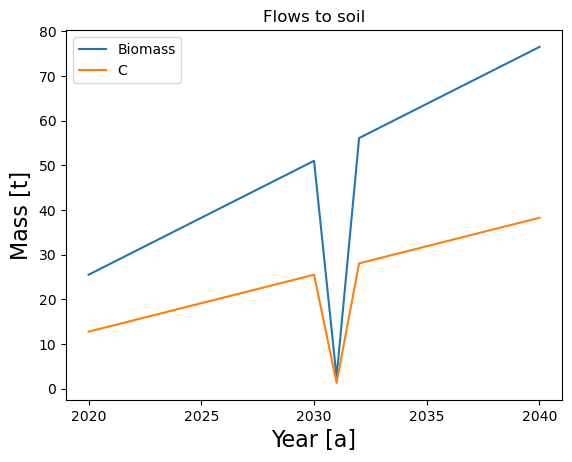

In [29]:
fig, ax = plt.subplots()

ax.plot(Dyn_MFA_System.IndexTable['Classification']['Time'].Items, 
        Dyn_MFA_System.FlowDict['F_4_9'].Values[:,0] + Dyn_MFA_System.FlowDict['F_5_9'].Values[:,0]) # [:,0] for all years and element Biomass
ax.plot(Dyn_MFA_System.IndexTable['Classification']['Time'].Items, 
        Dyn_MFA_System.FlowDict['F_4_9'].Values[:,1] + Dyn_MFA_System.FlowDict['F_5_9'].Values[:,1]) # [:,1] for all years and element Carbon

ax.set_ylabel('Mass [t]',fontsize = 16)
ax.set_xlabel('Year [a]',fontsize = 16)
ax.set_title("Flows to soil")
ax.legend(ModelClassification['Element'].Items)
ax.xaxis.set_major_locator(MultipleLocator(5))


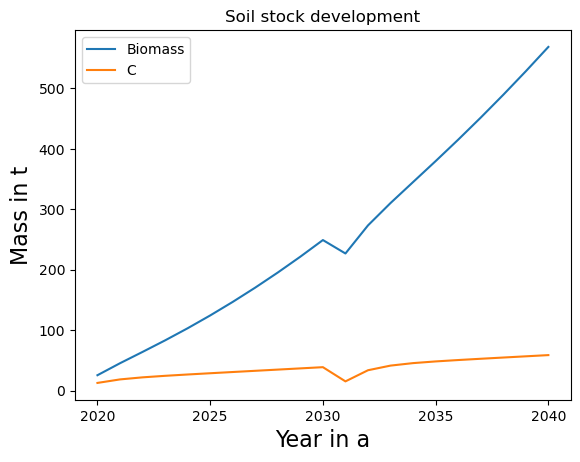

In [30]:
fig, ax = plt.subplots()

ax.plot(Dyn_MFA_System.IndexTable['Classification']['Time'].Items, 
        Dyn_MFA_System.StockDict['S_9'].Values[:,0]) # [:,0] for all years and element Biomass
ax.plot(Dyn_MFA_System.IndexTable['Classification']['Time'].Items, 
        Dyn_MFA_System.StockDict['S_9'].Values[:,1]) # [:,1] for all years and element Carbon
ax.set_ylabel('Mass in t',fontsize = 16)
ax.set_xlabel('Year in a',fontsize = 16)
ax.set_title("Soil stock development")
ax.legend(ModelClassification['Element'].Items)
ax.xaxis.set_major_locator(MultipleLocator(5))


### 4.2 Interactive Sankey diagram

In [31]:
# Choose colors for flows
colors_flows = []
colors_flows.extend(["darkseagreen" for i in range(3)])
colors_flows.extend(["skyblue" for i in range(11)])
colors_flows.extend(["salmon" for i in range(1)])

# Choose colors for processes
colors_processes = ["darkseagreen", "darkseagreen", "darkseagreen", "skyblue", "skyblue", "skyblue", 
               "skyblue", "skyblue", "skyblue", "salmon", "lavender", "lavender"
                  ]  


In [32]:
excluded_flows = {''}

bipl.sankey_results(Dyn_MFA_System, MyYears, ModelClassification, colors_flows, colors_processes, excluded_flows)

FigureWidget({
    'data': [{'link': {'color': [darkseagreen, darkseagreen, darkseagreen,
                                 skyblue, skyblue, skyblue, skyblue, skyblue,
                                 skyblue, skyblue, skyblue, skyblue, skyblue,
                                 skyblue, salmon],
                       'source': [0, 1, 1, 3, 3, 3, 3, 3, 4, 5, 5, 5, 6, 7, 9],
                       'target': [1, 2, 3, 4, 5, 6, 7, 8, 9, 9, 10, 11, 10, 10,
                                  10],
                       'value': [100.0, 50.0]},
              'node': {'color': [darkseagreen, darkseagreen, darkseagreen,
                                 skyblue, skyblue, skyblue, skyblue, skyblue,
                                 skyblue, salmon, lavender, lavender],
                       'label': [Cultivation, Harvesting, Food, Straw c&d,
                                 Incorporation, Composting, HTC, AD, Animal
                                 bedding, Soil, Atmosphere, Surface water and
   

interactive(children=(Dropdown(description='element:', options=('Biomass', 'C'), value='Biomass'), IntSlider(v…

### 4.3 Interactive stock plots

In [33]:
bipl.bar_stocks_results(Dyn_MFA_System, MyYears, ModelClassification, colors_processes)

FigureWidget({
    'data': [{'marker': {'color': ['darkseagreen', 'skyblue', 'salmon', 'lavender', 'lavender']},
              'type': 'bar',
              'uid': 'a12d0199-126b-4c85-ad91-ba0693fe4d3b',
              'x': [Food, Animal bedding, Soil, Atmosphere, Surface water and
                    aquifer],
              'y': [50.0, 25.0]}],
    'layout': {'template': '...', 'title': {'text': 'System stocks diagram Biomass (years 2020-2040) [t]'}}
})

interactive(children=(Dropdown(description='element:', options=('Biomass', 'C'), value='Biomass'), IntSlider(v…

### 4.4 Monte Carlo Simulation results

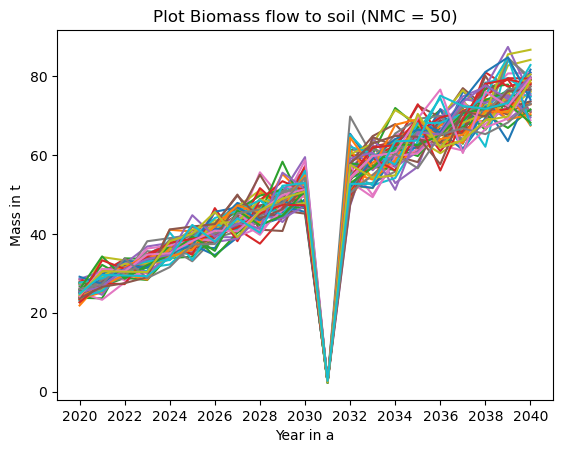

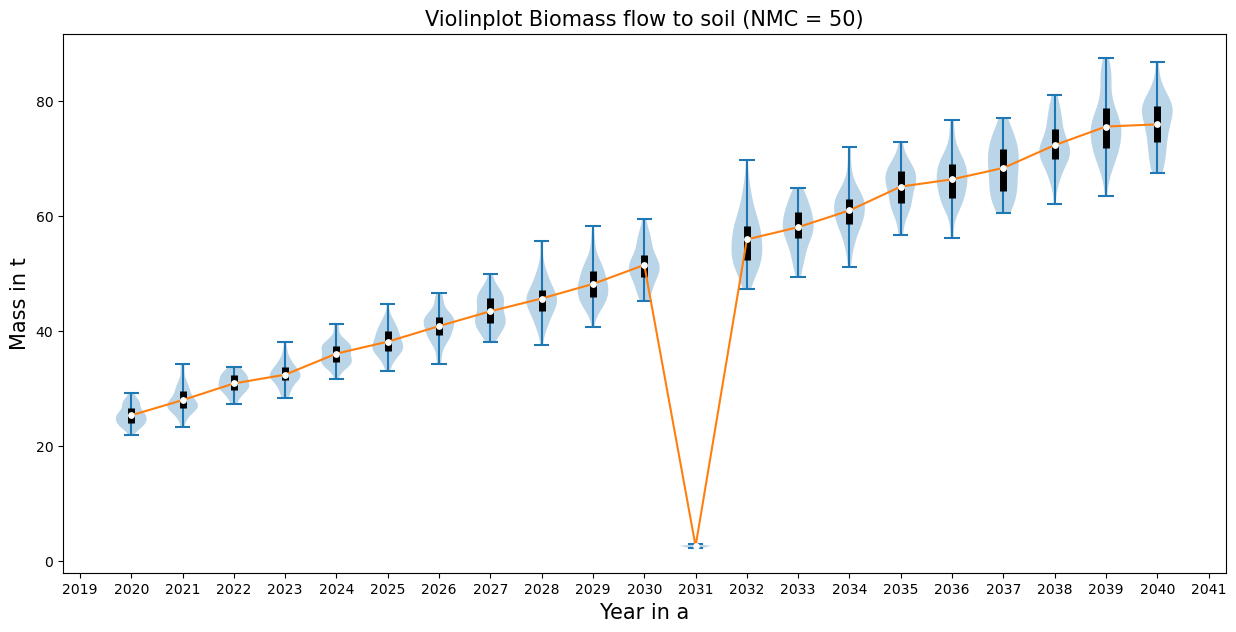

In [34]:
# Biomass flow to soil

fig, ax = plt.subplots()

#Simple plotting
for key in range(0, NMC):
        ax.plot(Dyn_MFA_System.IndexTable['Classification']['Time'].Items, 
            MC_BioInflowArray[key,:,0])

ax.set_title(f"Plot Biomass flow to soil (NMC = {NMC})")
ax.xaxis.set_major_locator(MultipleLocator(2))
ax.set_ylabel('Mass in t')
ax.set_xlabel('Year in a')




#Violing plotting showing data ranges, upper and lower quartil, mean values and probability density function
plt.figure(figsize = (15,7))
plt.violinplot(MC_BioInflowArray[:,:,0],positions = Dyn_MFA_System.IndexTable['Classification']['Time'].Items,
                widths=0.6)


quartile1, quartile3 = np.percentile(MC_BioInflowArray[:,:,0], [25, 75], axis=0)

plt.vlines(Dyn_MFA_System.IndexTable['Classification']['Time'].Items, quartile1, quartile3, color='k', linestyle='-', lw=5)
plt.scatter(Dyn_MFA_System.IndexTable['Classification']['Time'].Items, np.mean(MC_BioInflowArray[:,:,0], axis = 0), marker='o', color='white', s=15, zorder=3)
plt.plot(Dyn_MFA_System.IndexTable['Classification']['Time'].Items, np.mean(MC_BioInflowArray[:,:,0], axis = 0))

plt.title(f"Violinplot Biomass flow to soil (NMC = {NMC})", fontsize = 15)
plt.ylabel('Mass in t', fontsize = 15)
plt.xlabel('Year in a', fontsize = 15);
plt.xticks(np.arange(min(Dyn_MFA_System.IndexTable['Classification']['Time'].Items)-1, max(Dyn_MFA_System.IndexTable['Classification']['Time'].Items)+2, 1.0))



plt.show()

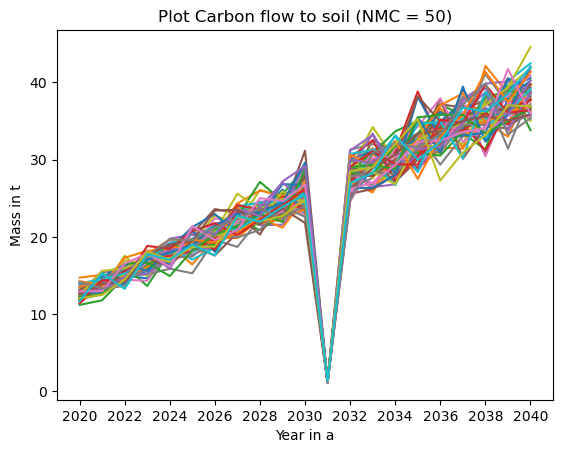

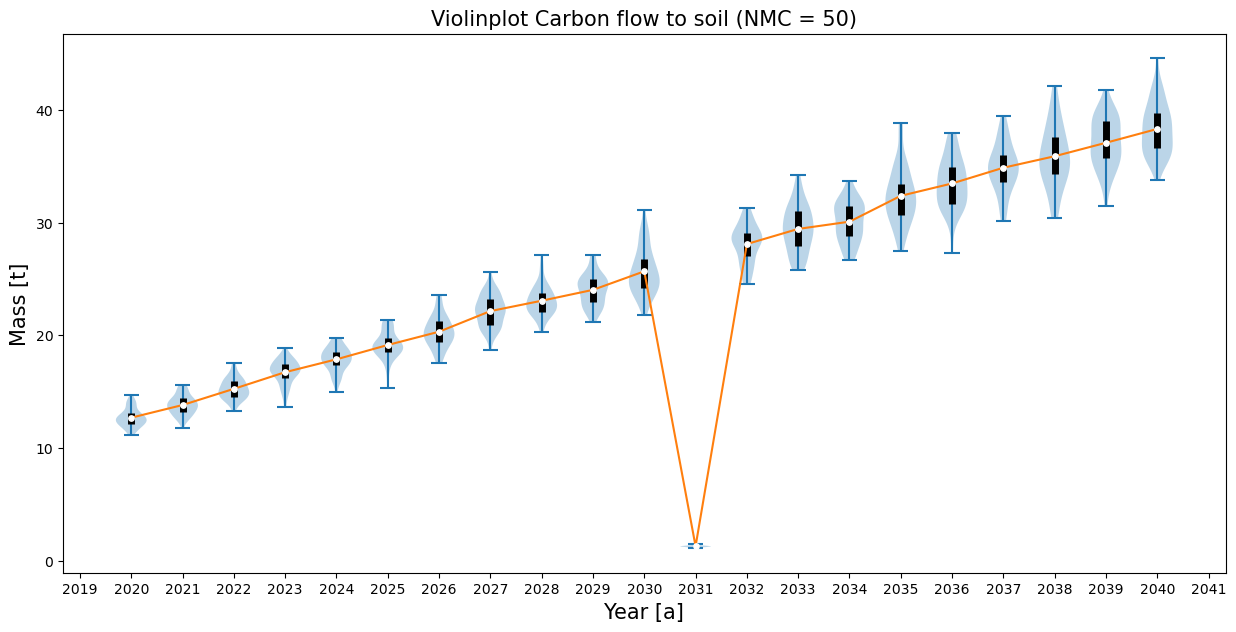

In [35]:
# Carbon flow to soil
fig, ax = plt.subplots()

#Simple plotting
for key in range(0, NMC):
        ax.plot(Dyn_MFA_System.IndexTable['Classification']['Time'].Items, 
            MC_BioInflowArray[key,:,1])

ax.set_title(f"Plot Carbon flow to soil (NMC = {NMC})")
ax.xaxis.set_major_locator(MultipleLocator(2))
ax.set_ylabel('Mass in t')
ax.set_xlabel('Year in a')




#Violing plotting showing data ranges, upper and lower quartil, mean values and probability density function
plt.figure(figsize = (15,7))
plt.violinplot(MC_BioInflowArray[:,:,1],positions = Dyn_MFA_System.IndexTable['Classification']['Time'].Items,
                widths=0.6)


quartile1, quartile3 = np.percentile(MC_BioInflowArray[:,:,1], [25, 75], axis=0)

plt.vlines(Dyn_MFA_System.IndexTable['Classification']['Time'].Items, quartile1, quartile3, color='k', linestyle='-', lw=5)
plt.scatter(Dyn_MFA_System.IndexTable['Classification']['Time'].Items, np.mean(MC_BioInflowArray[:,:,1], axis = 0), marker='o', color='white', s=15, zorder=3)
plt.plot(Dyn_MFA_System.IndexTable['Classification']['Time'].Items, np.mean(MC_BioInflowArray[:,:,1], axis = 0))

plt.title(f"Violinplot Carbon flow to soil (NMC = {NMC})", fontsize = 15)
plt.ylabel('Mass [t]', fontsize = 15)
plt.xlabel('Year [a]', fontsize = 15);
plt.xticks(np.arange(min(Dyn_MFA_System.IndexTable['Classification']['Time'].Items)-1, max(Dyn_MFA_System.IndexTable['Classification']['Time'].Items)+2, 1.0))



plt.show()

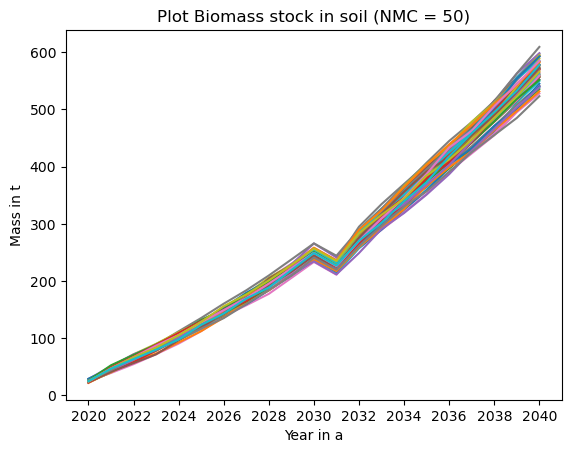

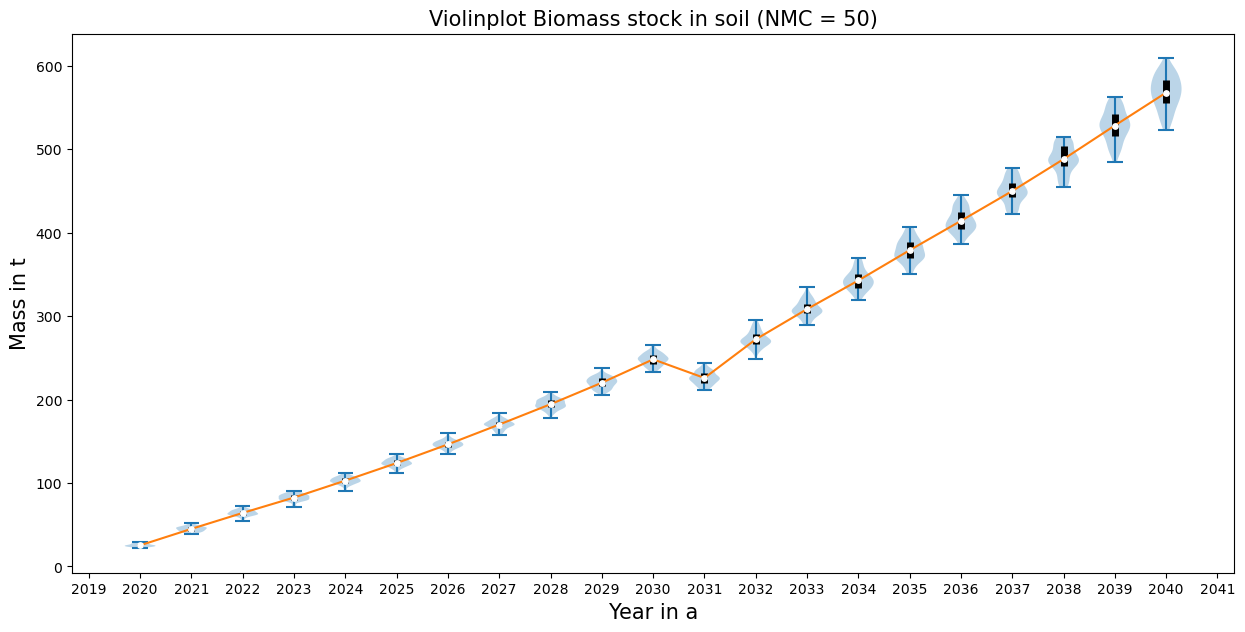

In [36]:
# Biomass stock in soil
fig, ax = plt.subplots()

#Simple plotting
for key in range(0, NMC):
        ax.plot(Dyn_MFA_System.IndexTable['Classification']['Time'].Items, 
            MC_StockDict['S_9'][key,:,0])

ax.set_title(f"Plot Biomass stock in soil (NMC = {NMC})")
ax.xaxis.set_major_locator(MultipleLocator(2))
ax.set_ylabel('Mass in t')
ax.set_xlabel('Year in a')




#Violing plotting showing data ranges, upper and lower quartil, mean values and probability density function
plt.figure(figsize = (15,7))
plt.violinplot(MC_StockDict['S_9'][:,:,0],positions = Dyn_MFA_System.IndexTable['Classification']['Time'].Items,
                widths=0.6)


quartile1, quartile3 = np.percentile(MC_StockDict['S_9'][:,:,0], [25, 75], axis=0)

plt.vlines(Dyn_MFA_System.IndexTable['Classification']['Time'].Items, quartile1, quartile3, color='k', linestyle='-', lw=5)
plt.scatter(Dyn_MFA_System.IndexTable['Classification']['Time'].Items, np.mean(MC_StockDict['S_9'][:,:,0], axis = 0), marker='o', color='white', s=15, zorder=3)
plt.plot(Dyn_MFA_System.IndexTable['Classification']['Time'].Items, np.mean(MC_StockDict['S_9'][:,:,0], axis = 0))

plt.title(f"Violinplot Biomass stock in soil (NMC = {NMC})", fontsize = 15)
plt.ylabel('Mass in t', fontsize = 15)
plt.xlabel('Year in a', fontsize = 15);
plt.xticks(np.arange(min(Dyn_MFA_System.IndexTable['Classification']['Time'].Items)-1, max(Dyn_MFA_System.IndexTable['Classification']['Time'].Items)+2, 1.0))



plt.show()

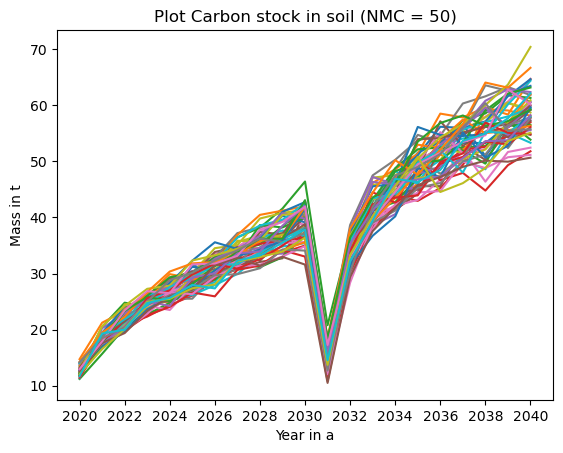

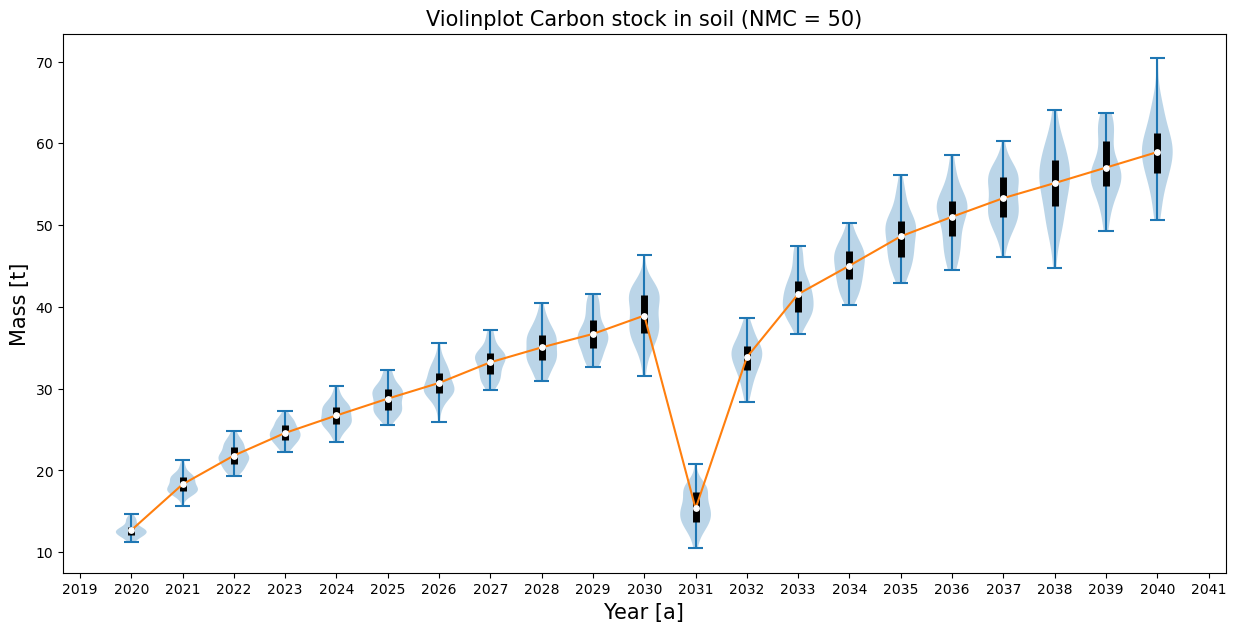

In [37]:
# Carbon stock in soil
fig, ax = plt.subplots()

#Simple plotting
for key in range(0, NMC):
        ax.plot(Dyn_MFA_System.IndexTable['Classification']['Time'].Items, 
            MC_StockDict['S_9'][key,:,1])

ax.set_title(f"Plot Carbon stock in soil (NMC = {NMC})")
ax.xaxis.set_major_locator(MultipleLocator(2))
ax.set_ylabel('Mass in t')
ax.set_xlabel('Year in a')




#Violing plotting showing data ranges, upper and lower quartil, mean values and probability density function
plt.figure(figsize = (15,7))
plt.violinplot(MC_StockDict['S_9'][:,:,1],positions = Dyn_MFA_System.IndexTable['Classification']['Time'].Items,
                widths=0.6)


quartile1, quartile3 = np.percentile(MC_StockDict['S_9'][:,:,1], [25, 75], axis=0)

plt.vlines(Dyn_MFA_System.IndexTable['Classification']['Time'].Items, quartile1, quartile3, color='k', linestyle='-', lw=5)
plt.scatter(Dyn_MFA_System.IndexTable['Classification']['Time'].Items, np.mean(MC_StockDict['S_9'][:,:,1], axis = 0), marker='o', color='white', s=15, zorder=3)
plt.plot(Dyn_MFA_System.IndexTable['Classification']['Time'].Items, np.mean(MC_StockDict['S_9'][:,:,1], axis = 0))

plt.title(f"Violinplot Carbon stock in soil (NMC = {NMC})", fontsize = 15)
plt.ylabel('Mass [t]', fontsize = 15)
plt.xlabel('Year [a]', fontsize = 15);
plt.xticks(np.arange(min(Dyn_MFA_System.IndexTable['Classification']['Time'].Items)-1, max(Dyn_MFA_System.IndexTable['Classification']['Time'].Items)+2, 1.0))



plt.show()

### 4.5 Export of results to Excel

In [38]:
# Export modeling results

bix.export_xlsx(Dyn_MFA_System, MyYears, ModelClassification)

In [39]:
# Export mean values of MCS along with absolute standard deviation values of all flows and stocks to Excel

flow_labels_new = []
for flow in MC_FlowDict:
    flow_labels_new.append(flow)
    flow_labels_new.append(f"{flow}_absSTD")

stock_labels_new = []
for stock in MC_StockDict:
    stock_labels_new.append(stock)
    stock_labels_new.append(f"{stock}_absSTD")
    
flows_Values_new = []
for flow in MC_FlowDict:
    flows_Values_new.append(np.mean(MC_FlowDict[flow], axis = 0))
    flows_Values_new.append(MC_FlowDict_absSTD[f"{flow}_absSTD"])
    

df_flows_Biomass = pd.DataFrame([i[:,0] for i in flows_Values_new]).T
df_flows_Biomass.columns = flow_labels_new
df_flows_Biomass['Years'] = MyYears
df_flows_Biomass.set_index('Years', inplace=True, drop=True)

df_flows_Carbon = pd.DataFrame([i[:,1] for i in flows_Values_new]).T
df_flows_Carbon.columns = flow_labels_new
df_flows_Carbon['Years'] = MyYears
df_flows_Carbon.set_index('Years', inplace=True, drop=True)


stock_Values_new = []
for stock in MC_StockDict:
    stock_Values_new.append(np.mean(MC_StockDict[stock], axis = 0))
    stock_Values_new.append(MC_StockDict_absSTD[f"{stock}_absSTD"])
    
df_stock_Biomass = pd.DataFrame([i[:,0] for i in stock_Values_new]).T
df_stock_Biomass.columns = stock_labels_new
df_stock_Biomass['Years'] = MyYears
df_stock_Biomass.set_index('Years', inplace=True, drop=True)

df_stock_Carbon = pd.DataFrame([i[:,1] for i in stock_Values_new]).T
df_stock_Carbon.columns = stock_labels_new
df_stock_Carbon['Years'] = MyYears
df_stock_Carbon.set_index('Years', inplace=True, drop=True)

folder = 'results'
file_path = os.path.join(folder, 'Case_study_results_MC_mean.xlsx')
# Create the folder if it doesn't exist
os.makedirs(folder, exist_ok=True)
writer = pd.ExcelWriter(file_path, engine='xlsxwriter')

df_flows_Biomass.to_excel(writer, sheet_name='MC_FlowDict_Biomass')
df_stock_Biomass.to_excel(writer, sheet_name='MC_StockDict_Biomass')


df_flows_Carbon.to_excel(writer, sheet_name='MC_FlowDict_Carbon')
df_stock_Carbon.to_excel(writer, sheet_name='MC_StockDict_Carbon')


writer.close()